In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN


I0000 00:00:1777977763.816001   16347 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777977763.853294   16347 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777977764.897477   16347 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [10]:
data=pd.read_csv('google.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602


In [11]:
data=data[['Open']]

In [12]:
scaler=MinMaxScaler()
data_scaled=scaler.fit_transform(data)

In [13]:
X=[]
y=[]

for i in range(60,len(data_scaled)):
    X.append(data_scaled[i-60:i])
    y.append(data_scaled[i])
X,y=np.array(X),np.array(y)

In [17]:
X=np.reshape(X,(X.shape[0],X.shape[1],1))

In [22]:
model=Sequential([
    SimpleRNN(50,activation='tanh',input_shape=(60,1)),
    Dense(1)
])

In [23]:
model.compile(optimizer='adam',loss='mse')

In [24]:
model.fit(X,y,epochs=10,batch_size=32,verbose=1)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8594e-04
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4264e-04
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1106e-04
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2857e-04
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0341e-04
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.7951e-05
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4487e-05
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4337e-05
Epoch 10/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.6904e-05


In [31]:
pred=model.predict(X)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [32]:
print(pred)

[[0.01036847]
 [0.01082446]
 [0.01133555]
 ...
 [0.8744336 ]
 [0.896921  ]
 [0.8965294 ]]


<function matplotlib.pyplot.show(close=None, block=None)>

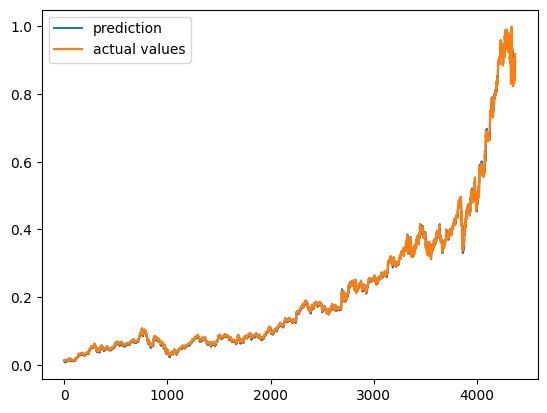

In [33]:
plt.plot(pred,label="prediction")
plt.plot(y,label='actual values')
plt.legend()
plt.show